# Solar Flare ML Prediction - Cycle-to-Cycle Transfer Learning

This notebook demonstrates training on Solar Cycle 22 and testing on Solar Cycle 23 to assess cross-cycle generalization and model robustness.

## 1. Import and Setup

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc, accuracy_score,
    precision_score, recall_score, f1_score, brier_score_loss
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from numpy import interp
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (13, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Define Skill Score Functions

In [17]:
def tss_calc(conf_table):
    """
    Calculate True Skill Statistic (TSS)
    TSS = POD - POFD where POD = TP Rate, POFD = FP Rate
    """
    TP = conf_table[1, 1]
    TN = conf_table[0, 0]
    FP = conf_table[0, 1]
    FN = conf_table[1, 0]
    POD = TP / (TP + FN) if (TP + FN) > 0 else 0
    POFD = FP / (TN + FP) if (TN + FP) > 0 else 0
    return POD - POFD

def bss_calc(Y_val, predict_probs):
    """
    Calculate Brier Skill Score (BSS)
    BSS = 1 - (BS / BS_clim)
    """
    clim_arr = np.full(len(Y_val), np.mean(Y_val))
    bs_metric = brier_score_loss(Y_val, predict_probs)
    bs_metric_clim = brier_score_loss(Y_val, clim_arr)
    return 1. - bs_metric / bs_metric_clim

print("Skill score functions defined")

Skill score functions defined


## 3. Load and Prepare Data from Both Cycles

In [18]:
# Load datasets
names = ['mcint', 'mcint_evol', 'class']
df_train = pd.read_csv('../mcint_ml22.csv', names=names,
                        dtype={'mcint': str, 'mcint_evol': str, 'class': np.float64})
df_test = pd.read_csv('../mcint_ml23.csv', names=names,
                       dtype={'mcint': str, 'mcint_evol': str, 'class': np.float64})

print(f"Solar Cycle 22 (Training): {df_train.shape[0]} samples")
print(f"Solar Cycle 23 (Testing): {df_test.shape[0]} samples")
print(f"\nClass distribution (Cycle 22):")
print(df_train['class'].value_counts().sort_index())
print(f"\nClass distribution (Cycle 23):")
print(df_test['class'].value_counts().sort_index())

Solar Cycle 22 (Training): 14251 samples
Solar Cycle 23 (Testing): 18170 samples

Class distribution (Cycle 22):
class
0.0    11346
1.0     2905
Name: count, dtype: int64

Class distribution (Cycle 23):
class
0.0    14788
1.0     3382
Name: count, dtype: int64


## 4. Feature Engineering

In [19]:
# Encode McIntosh classifications
le = preprocessing.LabelEncoder()

# Train encoding on combined data to ensure consistency
all_mcint = pd.concat([df_train['mcint'], df_test['mcint']])
all_mcint_evol = pd.concat([df_train['mcint_evol'], df_test['mcint_evol']])

le_mcint = preprocessing.LabelEncoder()
le_mcint.fit(all_mcint)

le_evol = preprocessing.LabelEncoder()
le_evol.fit(all_mcint_evol)

# Apply encoding to both datasets
df_train['mcint_enc'] = le_mcint.transform(df_train['mcint'])
df_train['mcint_evol_enc'] = le_evol.transform(df_train['mcint_evol'])

df_test['mcint_enc'] = le_mcint.transform(df_test['mcint'])
df_test['mcint_evol_enc'] = le_evol.transform(df_test['mcint_evol'])

# Parse evolution codes with proper error handling
for df in [df_train, df_test]:
    df['z1'] = df['mcint'].str[0].apply(lambda x: 0 if (pd.isna(x) or x == '-') else int(x))
    df['p1'] = df['mcint'].str[1].apply(lambda x: 0 if (pd.isna(x) or x == '-') else int(x))
    df['c1'] = df['mcint'].str[2].apply(lambda x: 0 if (pd.isna(x) or x == '-') else int(x))
    df['z2'] = df['mcint'].str[3].apply(lambda x: 0 if (pd.isna(x) or x == '-') else int(x))
    df['p2'] = df['mcint'].str[4].apply(lambda x: 0 if (pd.isna(x) or x == '-') else int(x))
    df['c2'] = df['mcint'].str[5].apply(lambda x: 0 if (pd.isna(x) or x == '-') else int(x))

# Select features
feature_cols = ['z1', 'p1', 'c1', 'z2', 'p2', 'c2']
X_train = df_train[feature_cols].fillna(0)
Y_train = df_train['class']
X_test = df_test[feature_cols].fillna(0)
Y_test = df_test['class']

print(f"Features selected: {feature_cols}")
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nSample values (first 5):") 
print(X_train.head())

Features selected: ['z1', 'p1', 'c1', 'z2', 'p2', 'c2']
Training set: (14251, 6)
Test set: (18170, 6)

Sample values (first 5):
   z1  p1  c1  z2  p2  c2
0   1   0   0   0   0   0
1   1   2   0   0   0   0
2   1   2   0   0   0   0
3   1   0   0   0   0   0
4   1   0   0   0   0   0


## 5. Train Models on Solar Cycle 22

In [20]:
# Define machine learning models
models = [
    ('LR', LogisticRegression(max_iter=1000)),
    ('LDA', LinearDiscriminantAnalysis()),
    ('KNN', KNeighborsClassifier()),
    ('CART', DecisionTreeClassifier()),
    ('RFC', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('SVM', SVC(kernel='rbf', probability=True))
]

# Train models on Cycle 22
trained_models = {}
print("Training models on Solar Cycle 22...\n")

for name, model in models:
    model.fit(X_train, Y_train)
    trained_models[name] = model
    print(f"✓ {name} trained")

print("\nAll models trained successfully!")

Training models on Solar Cycle 22...

✓ LR trained
✓ LDA trained
✓ KNN trained
✓ CART trained
✓ RFC trained
✓ SVM trained

All models trained successfully!


## 6. Test Models on Solar Cycle 23

In [23]:
# Evaluate models on test set
results = {}
print("\nEvaluating on Solar Cycle 23...\n")
print(f"{'Algorithm':<12} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'BSS':<12} {'TSS':<12}")
print("-" * 90)

for name, model in trained_models.items():
    # Get predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(Y_test, y_pred)
    precision = precision_score(Y_test, y_pred, zero_division=0)
    recall = recall_score(Y_test, y_pred, zero_division=0)
    f1 = f1_score(Y_test, y_pred, zero_division=0)
    bss = bss_calc(Y_test, y_proba)
    
    conf_mat = confusion_matrix(Y_test, y_pred)
    tss = tss_calc(conf_mat)
    
    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'bss': bss,
        'tss': tss,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'conf_mat': conf_mat
    }
    
    print(f"{name:<12} {accuracy:<12.4f} {precision:<12.4f} {recall:<12.4f} {f1:<12.4f} {bss:<12.4f} {tss:<12.4f}")

print("\n✓ Evaluation complete!")


Evaluating on Solar Cycle 23...

Algorithm    Accuracy     Precision    Recall       F1           BSS          TSS         
------------------------------------------------------------------------------------------
LR           0.8062       0.4638       0.2655       0.3377       0.1314       0.1953      
LDA          0.8106       0.4868       0.3214       0.3872       0.0973       0.2439      
KNN          0.8193       0.5256       0.2978       0.3801       0.0549       0.2363      
CART         0.8386       0.6083       0.3737       0.4630       0.2157       0.3187      
RFC          0.8390       0.6090       0.3776       0.4661       0.2162       0.3221      
SVM          0.8374       0.6436       0.2836       0.3937       0.1293       0.2477      

✓ Evaluation complete!


## 7. ROC Curves - All Models Compared

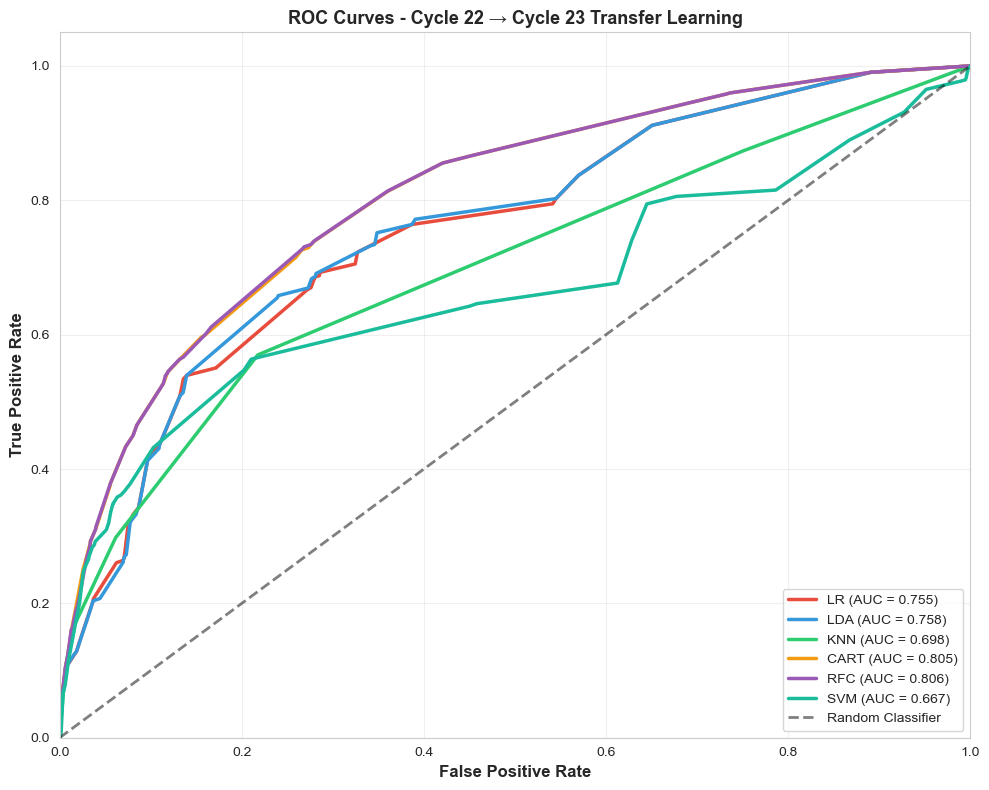

ROC curves plotted!


In [27]:
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for (name, model), color in zip(trained_models.items(), colors):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(Y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{name} (AUC = {roc_auc:.3f})')

# Random classifier baseline
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier', alpha=0.5)

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curves - Cycle 22 → Cycle 23 Transfer Learning', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("ROC curves plotted!")

## 8. Confusion Matrices

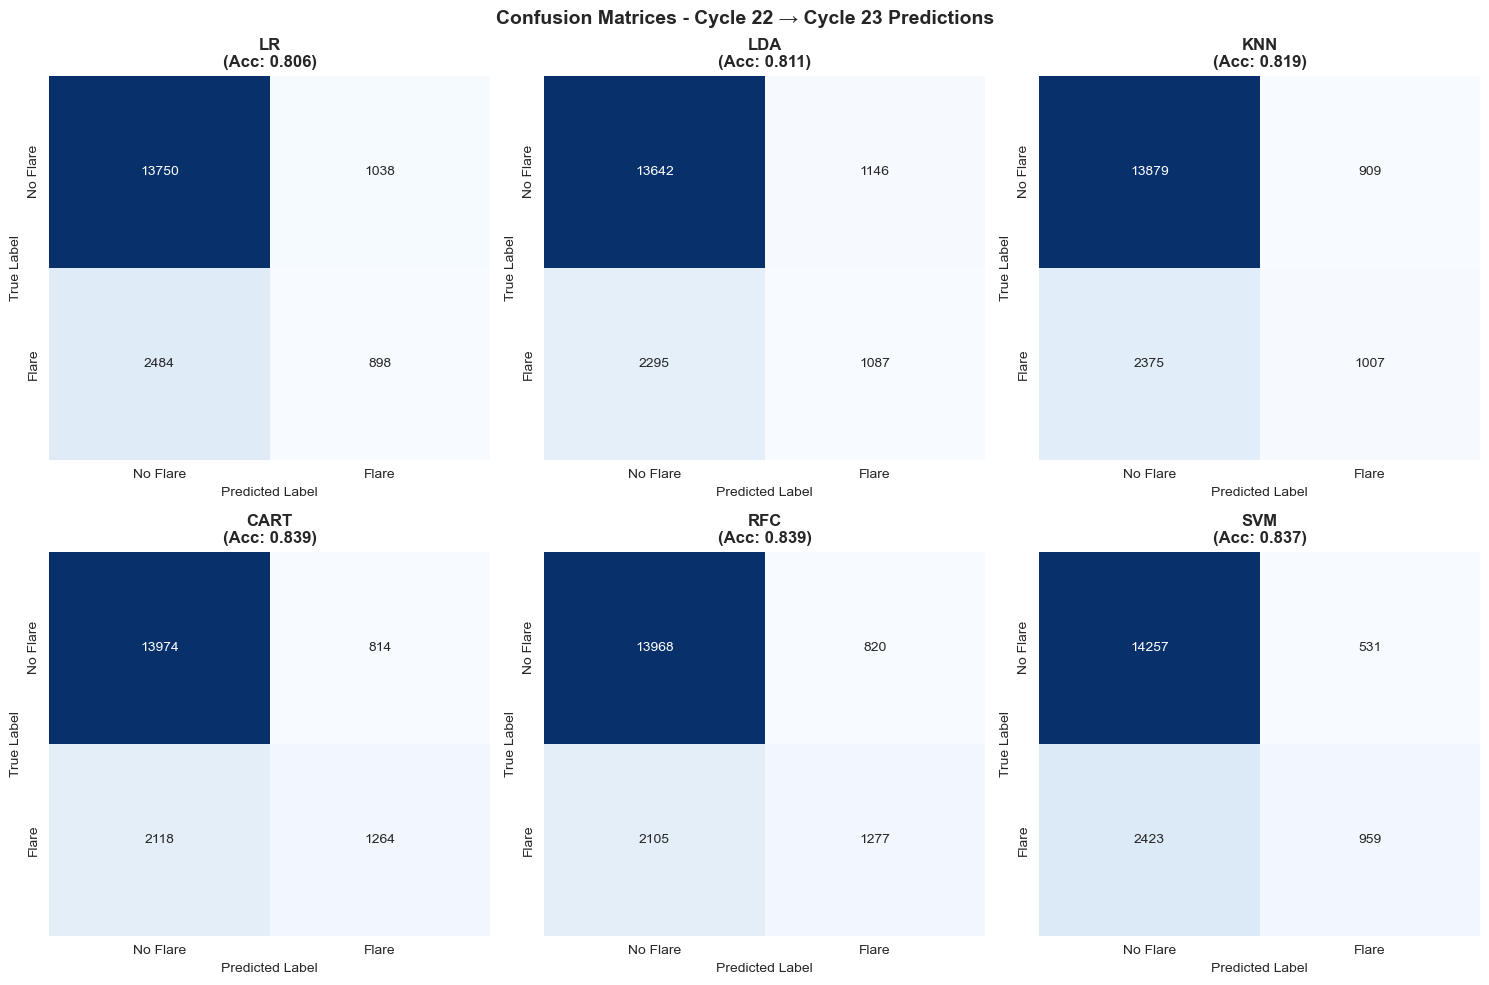

Confusion matrices plotted!


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Confusion Matrices - Cycle 22 → Cycle 23 Predictions', fontsize=14, fontweight='bold')

for ax, (name, result) in zip(axes.flat, results.items()):
    cm = result['conf_mat']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['No Flare', 'Flare'],
                yticklabels=['No Flare', 'Flare'])
    ax.set_title(f"{name}\n(Acc: {result['accuracy']:.3f})", fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

print("Confusion matrices plotted!")

## 9. Performance Metrics Comparison

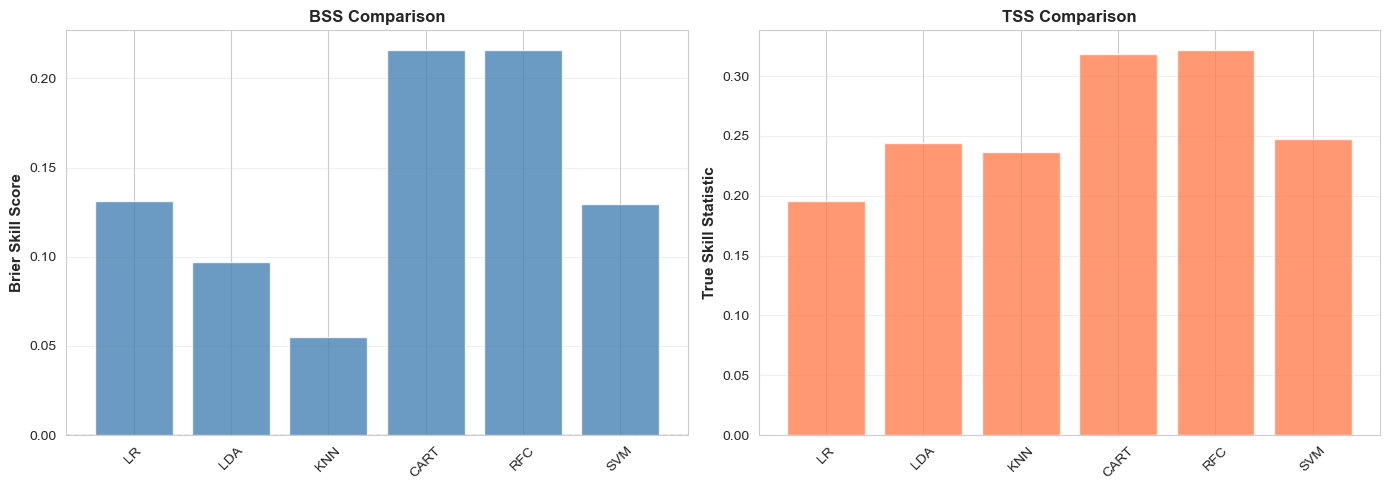

Metrics comparison plotted!


In [28]:
# Create comparison dataframe
metrics_df = pd.DataFrame({
    'Algorithm': list(results.keys()),
    'Accuracy': [results[name]['accuracy'] for name in results.keys()],
    'Precision': [results[name]['precision'] for name in results.keys()],
    'Recall': [results[name]['recall'] for name in results.keys()],
    'F1-Score': [results[name]['f1'] for name in results.keys()],
    'BSS': [results[name]['bss'] for name in results.keys()],
    'TSS': [results[name]['tss'] for name in results.keys()]
})

# Plot metrics comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BSS Comparison
axes[0].bar(metrics_df['Algorithm'], metrics_df['BSS'], color='steelblue', alpha=0.8)
axes[0].axhline(y=0, color='gray', linestyle='--', linewidth=1)
axes[0].set_ylabel('Brier Skill Score', fontsize=11, fontweight='bold')
axes[0].set_title('BSS Comparison', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=45)

# TSS Comparison
axes[1].bar(metrics_df['Algorithm'], metrics_df['TSS'], color='coral', alpha=0.8)
axes[1].set_ylabel('True Skill Statistic', fontsize=11, fontweight='bold')
axes[1].set_title('TSS Comparison', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Metrics comparison plotted!")

## 10. Summary Table

In [29]:
print("\n" + "="*110)
print("CYCLE-TO-CYCLE TRANSFER LEARNING SUMMARY")
print("Training: Solar Cycle 22 | Testing: Solar Cycle 23")
print("="*110)
print()
print(metrics_df.round(4).to_string(index=False))
print()
print("="*110)

# Best performers
best_accuracy = metrics_df.loc[metrics_df['Accuracy'].idxmax()]
best_bss = metrics_df.loc[metrics_df['BSS'].idxmax()]
best_tss = metrics_df.loc[metrics_df['TSS'].idxmax()]

print(f"\n🏆 Best Accuracy: {best_accuracy['Algorithm']} ({best_accuracy['Accuracy']:.4f})")
print(f"🏆 Best BSS: {best_bss['Algorithm']} ({best_bss['BSS']:.4f})")
print(f"🏆 Best TSS: {best_tss['Algorithm']} ({best_tss['TSS']:.4f})")

print("\n✓ Transfer learning analysis complete!")


CYCLE-TO-CYCLE TRANSFER LEARNING SUMMARY
Training: Solar Cycle 22 | Testing: Solar Cycle 23

Algorithm  Accuracy  Precision  Recall  F1-Score    BSS    TSS
       LR    0.8062     0.4638  0.2655    0.3377 0.1314 0.1953
      LDA    0.8106     0.4868  0.3214    0.3872 0.0973 0.2439
      KNN    0.8193     0.5256  0.2978    0.3801 0.0549 0.2363
     CART    0.8386     0.6083  0.3737    0.4630 0.2157 0.3187
      RFC    0.8390     0.6090  0.3776    0.4661 0.2162 0.3221
      SVM    0.8374     0.6436  0.2836    0.3937 0.1293 0.2477


🏆 Best Accuracy: RFC (0.8390)
🏆 Best BSS: RFC (0.2162)
🏆 Best TSS: RFC (0.3221)

✓ Transfer learning analysis complete!
